In [1]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_validate

# Load dataset

In [3]:
pd.read_excel("diamonds.xlsx")
df = pd.read_excel("diamonds.xlsx")

In [4]:
# Remove unnecessary index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.head())

   carat      cut color clarity  depth  table     x     y     z  price
0   0.23    Ideal     E     SI2   61.5   55.0  3.95  3.98  2.43    326
1   0.21  Premium     E     SI1   59.8   61.0  3.89  3.84  2.31    326
2   0.23     Good     E     VS1   56.9   65.0  4.05  4.07  2.31    327
3   0.29  Premium     I     VS2   62.4   58.0  4.20  4.23  2.63    334
4   0.31     Good     J     SI2   63.3   58.0  4.34  4.35  2.75    335


In [5]:
# Define predictors and target
X = df.drop("price", axis=1)
y = df["price"]

# Data preprocessing

In [7]:
# Remove index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop("Unnamed: 0", axis=1)

In [8]:
# Define predictors and target
X = df.drop("price", axis=1)
y = df["price"]


In [9]:
# Create column lists
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

In [10]:
# Build preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

# Multiple Linear Regression

In [11]:
model = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

# Cross-validation

In [14]:
cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)
scores = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring={
        'rmse':'neg_root_mean_squared_error',
        'r2':'r2'
    }
)

rmse = -scores['test_rmse']
r2 = scores['test_r2']

print("\nCross Validation Results")
print("Mean RMSE:", rmse.mean())
print("Mean R²:", r2.mean())


Cross Validation Results
Mean RMSE: 1130.678799297432
Mean R²: 0.9195906872738266


# LASSO Variable Selection

In [15]:
# Transform predictors
X_processed = preprocessor.fit_transform(X)

In [16]:
# Get feature names
feature_names = (
    list(num_cols) +
    list(preprocessor.named_transformers_[
        'cat'
    ].get_feature_names_out(cat_cols))
)

In [17]:
# LASSO with automatic tuning
lasso = LassoCV(cv=10, random_state=42)
lasso.fit(X_processed, y)

LassoCV(cv=10, random_state=42)

In [18]:
# Selected variables
lasso_selected = pd.DataFrame({
    'Variable': feature_names,
    'Coefficient': lasso.coef_
})

lasso_selected = lasso_selected[
    lasso_selected['Coefficient'] != 0
]

print("\nLASSO Selected Variables:")
print(lasso_selected)


LASSO Selected Variables:
         Variable  Coefficient
0           carat  5114.844382
1           depth  -124.894297
2           table   -81.782893
3               x  -964.709167
5               z   -21.902979
6        cut_Good   201.347174
7       cut_Ideal   467.609080
8     cut_Premium   392.090129
9   cut_Very Good   377.078784
10        color_E   -14.480216
11        color_F   -78.472042
12        color_G  -271.631748
13        color_H  -765.598416
14        color_I -1214.280045
15        color_J -2071.338306
16     clarity_IF  3312.282243
17    clarity_SI1  1782.835074
18    clarity_SI2   835.589677
19    clarity_VS1  2655.968720
20    clarity_VS2  2373.082863
21   clarity_VVS1  3045.098556
22   clarity_VVS2  3015.777909


# Recursive Feature Elimination


In [19]:
rfecv = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=10,
    scoring='r2'
)

rfecv.fit(X_processed, y)
selected_features = np.array(feature_names)[
    rfecv.support_
]

print("\nRFECV Selected Features:")
print(selected_features)

print("\nOptimal Number of Features:")
print(rfecv.n_features_)


RFECV Selected Features:
['carat']

Optimal Number of Features:
1


In [20]:
lasso_selected.to_csv("lasso_results.csv", index=False)

pd.DataFrame(
    {"Selected Features": selected_features}
).to_csv("rfecv_results.csv", index=False)

print("Files saved")

Files saved


In [21]:
# Check which variables are most important
lasso_selected = lasso_selected.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print(lasso_selected)

         Variable  Coefficient
0           carat  5114.844382
16     clarity_IF  3312.282243
21   clarity_VVS1  3045.098556
22   clarity_VVS2  3015.777909
19    clarity_VS1  2655.968720
20    clarity_VS2  2373.082863
15        color_J -2071.338306
17    clarity_SI1  1782.835074
14        color_I -1214.280045
3               x  -964.709167
18    clarity_SI2   835.589677
13        color_H  -765.598416
7       cut_Ideal   467.609080
8     cut_Premium   392.090129
9   cut_Very Good   377.078784
12        color_G  -271.631748
6        cut_Good   201.347174
1           depth  -124.894297
2           table   -81.782893
11        color_F   -78.472042
5               z   -21.902979
10        color_E   -14.480216


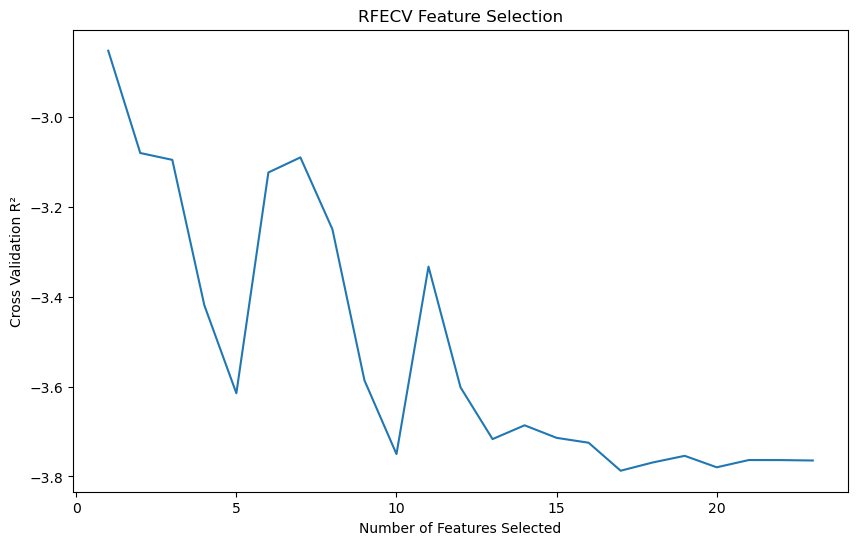

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(
    range(1, len(rfecv.cv_results_['mean_test_score'])+1),
    rfecv.cv_results_['mean_test_score']
)

plt.xlabel("Number of Features Selected")
plt.ylabel("Cross Validation R²")
plt.title("RFECV Feature Selection")
plt.show()

# Results

# Predictive Model Performance (10-Fold Cross Validation)

| Metric    |   Value |
| --------- | ------: |
| Mean RMSE | 1130.68 |
| Mean R²   |  0.9196 |

# Interpretation:

* The model explains approximately **91.96% of the variation in diamond prices**.
* The average prediction error is approximately **1130.68 price units**.
* Since the R² value is close to 1, the model demonstrates **strong predictive performance**.

---

### Variable Selection Using LASSO

LASSO retained the following variables:

**Numerical predictors**

* carat
* depth
* table
* x
* z

**Cut variables**

* Good
* Ideal
* Premium
* Very Good

**Color variables**

* E
* F
* G
* H
* I
* J

**Clarity variables**

* IF
* SI1
* SI2
* VS1
* VS2
* VVS1
* VVS2

Total variables selected by LASSO: **23**

Key observations:

* **carat (5114.84)** has the largest positive coefficient, making it the strongest predictor.
* Higher clarity grades such as **IF**, **VVS1**, and **VVS2** increase price considerably.
* Lower color grades (H, I, J) have negative coefficients, indicating reduced prices.

---

### Variable Selection Using RFECV

RFECV selected:

* **carat**

Optimal number of features:

* **1**

Interpretation:

RFECV determined that **carat alone provides the strongest predictive contribution**. 
This suggests that diamond weight is the dominant factor affecting price in the dataset.

---

## Final conclusion for your assignment

You can directly paste this:

> A predictive model was developed using multiple linear regression to estimate diamond prices. 
Ten-fold cross-validation was used to evaluate model performance. The model achieved 
    a mean RMSE of 1130.68 and a mean R² value of 0.9196, indicating strong predictive 
accuracy and good generalization capability. Variable selection techniques were also applied 
using LASSO and RFECV. LASSO retained 23 significant predictors including carat, diamond dimensions,
and quality-related variables such as cut, color, and clarity. RFECV selected only carat as the optimal 
predictor, indicating that diamond weight is the most influential variable for predicting price. Overall, 
carat was identified as the strongest determinant of diamond price.


